<a href="https://colab.research.google.com/github/daniballester-ai/mr_health_demand_forecast/blob/main/notebooks/mr_health_demand_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Mr. Health — Análise Exploratória e Modelo Preditivo de Demanda

**Processo seletivo DataLakers**

Este notebook contém:

1. Ingestão e padronização dos dados de vendas da Mr. Health.
2. Verificação de qualidade de dados e reconstrução do valor total por pedido.
3. Análise exploratória (EDA) do comportamento de vendas.
4. Benchmark de modelos preditivos de demanda (rede) com validação cruzada temporal.
5. Previsão de demanda por item.
6. Avaliação final e recomendações de negócio para gestão de estoque.

In [ ]:
# --- Setup do ambiente: local ou Google Colab ---
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

# Preencha com a URL do repositório assim que ele existir no GitHub, por
# exemplo "https://github.com/<usuario>/<repositorio>.git". Enquanto estiver
# vazio, o notebook no Colab pede para enviar os arquivos manualmente.
GITHUB_REPO_URL = ""
GITHUB_BRANCH = "main"

if IN_COLAB:
    # Dependências que não vêm pré-instaladas por padrão no Colab.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "lightgbm", "openpyxl"], check=False)

    if GITHUB_REPO_URL:
        # Clona o repositório (uma única vez) e usa sua raiz como DATA_DIR.
        repo_dir = Path("/content") / Path(GITHUB_REPO_URL).stem
        if not repo_dir.exists():
            subprocess.run(
                ["git", "clone", "--branch", GITHUB_BRANCH, "--depth", "1", GITHUB_REPO_URL, str(repo_dir)],
                check=True,
            )
        DATA_DIR = repo_dir
        sys.path.insert(0, str(DATA_DIR / "src"))
    else:
        # Sem repositório ainda: pede upload manual dos 3 arquivos de dados
        # e do módulo compartilhado, e monta um pacote `mrhealth` local.
        from google.colab import files

        print(
            "GITHUB_REPO_URL não foi preenchido. Envie quando solicitado: "
            "PEDIDO-_1_.xlsx, ITEM_PEDIDO-_2_.xlsx, ITENS-_3_.xlsx e pipeline.py "
            "(de src/mrhealth/pipeline.py)."
        )
        uploaded = files.upload()

        DATA_DIR = Path("/content")
        mrhealth_dir = DATA_DIR / "mrhealth"
        mrhealth_dir.mkdir(exist_ok=True)
        (mrhealth_dir / "__init__.py").touch()
        if "pipeline.py" in uploaded:
            (mrhealth_dir / "pipeline.py").write_bytes(uploaded["pipeline.py"])
        sys.path.insert(0, str(DATA_DIR))
else:
    # Execução local: arquivos de dados ficam na raiz do projeto, este script em notebooks/.
    DATA_DIR = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path.cwd().parent
    sys.path.insert(0, str(DATA_DIR / "src"))

GITHUB_REPO_URL não foi preenchido. Envie quando solicitado: PEDIDO-_1_.xlsx, ITEM_PEDIDO-_2_.xlsx, ITENS-_3_.xlsx e pipeline.py (de src/mrhealth/pipeline.py).


Saving ITEM_PEDIDO-_2_.xlsx to ITEM_PEDIDO-_2_.xlsx
Saving ITENS-_3_.xlsx to ITENS-_3_.xlsx
Saving PEDIDO-_1_.xlsx to PEDIDO-_1_.xlsx


In [ ]:
# --- Imports e configuração geral ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import mrhealth.pipeline as pl  # noqa: E402

# Reprodutibilidade
np.random.seed(pl.RANDOM_STATE)

# Estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Exibição do pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Diretório de dados:", DATA_DIR)

Diretório de dados: /content


## 1. Ingestão e padronização dos dados

Os três arquivos de origem representam:
- `PEDIDO`: um pedido por linha (data e valor total — hoje vazio).
- `ITEM_PEDIDO`: os itens vendidos em cada pedido, com quantidade.
- `ITENS`: o catálogo de produtos com o preço unitário (exportado sem
  cabeçalho de dados válido — tratado à parte em `pl.carregar_dados`).

In [ ]:
# --- Carga e padronização (ingestão + correção do catálogo ITENS) ---
df_pedido, df_item_pedido, df_itens = pl.carregar_dados(DATA_DIR)

print("PEDIDO:", df_pedido.shape)
print(df_pedido.dtypes)
print(df_pedido.head(3))
print()
print("ITEM_PEDIDO:", df_item_pedido.shape)
print(df_item_pedido.dtypes)
print(df_item_pedido.head(3))
print()
print("Catálogo de itens corrigido:")
print(df_itens)

assert df_itens.shape[0] == 4, "Catálogo deveria conter exatamente 4 itens (A-D)"

PEDIDO: (181, 3)
ID_PEDIDO               int64
DATA           datetime64[ns]
VALOR_TOTAL           float64
dtype: object
   ID_PEDIDO       DATA  VALOR_TOTAL
0  120210601 2021-06-01          NaN
1  220210601 2021-06-01          NaN
2  320210604 2021-06-04          NaN

ITEM_PEDIDO: (295, 3)
ID_PEDIDO      int64
ID_ITEM       object
QUANTIDADE     int64
dtype: object
   ID_PEDIDO ID_ITEM  QUANTIDADE
0  120210601  item C           4
1  220210601  item A           3
2  320210604  item C           1

Catálogo de itens corrigido:
  ID_ITEM  PRECO_UNITARIO
0  item A            10.0
1  item B            15.0
2  item C            20.0
3  item D            25.0


## 2. Qualidade de dados e reconstrução do valor total

A coluna `VALOR_TOTAL` de `PEDIDO` está 100% vazia. Antes de qualquer
modelagem, reportamos esse e outros problemas de qualidade de dados e
reconstruímos o valor a partir do join entre os itens vendidos e o
catálogo de preços.

In [ ]:
# --- Diagnóstico de qualidade de dados ---
diagnostico = pl.diagnosticar_qualidade(df_pedido, df_item_pedido, df_itens)

print(f"% de VALOR_TOTAL nulo em PEDIDO: {diagnostico.pct_valor_total_nulo:.1f}%")
print(f"IDs de pedido duplicados em PEDIDO: {diagnostico.duplicados_pedido}")
print(f"Combinações (ID_PEDIDO, ID_ITEM) repetidas em ITEM_PEDIDO: {diagnostico.duplicados_item_pedido}")
print(f"  das quais, linhas 100% idênticas (mesmo pedido/item/quantidade): {diagnostico.duplicados_exatos}")
print(f"Pedidos em PEDIDO sem nenhum item em ITEM_PEDIDO: {diagnostico.pedidos_sem_itens}")
print(f"Registros em ITEM_PEDIDO cujo pedido não existe em PEDIDO: {diagnostico.itens_sem_pedido}")
print(f"IDs de item em ITEM_PEDIDO ausentes do catálogo ITENS: {diagnostico.itens_desconhecidos}")

% de VALOR_TOTAL nulo em PEDIDO: 100.0%
IDs de pedido duplicados em PEDIDO: 0
Combinações (ID_PEDIDO, ID_ITEM) repetidas em ITEM_PEDIDO: 15
  das quais, linhas 100% idênticas (mesmo pedido/item/quantidade): 4
Pedidos em PEDIDO sem nenhum item em ITEM_PEDIDO: 0
Registros em ITEM_PEDIDO cujo pedido não existe em PEDIDO: 0
IDs de item em ITEM_PEDIDO ausentes do catálogo ITENS: set()


**Achados e decisões de tratamento:**
- `VALOR_TOTAL` está vazio em 100% dos pedidos — precisa ser reconstruído
  (tratado na próxima célula).
- Não há duplicidade de `ID_PEDIDO` em `PEDIDO`.
- Existem combinações `(ID_PEDIDO, ID_ITEM)` repetidas em `ITEM_PEDIDO`
  (o mesmo item aparece em mais de uma linha do mesmo pedido). Na maioria
  dos casos as quantidades são diferentes entre as linhas — consistente
  com múltiplas linhas de pedido legítimas para o mesmo produto (ex.: item
  incluído em dois momentos do mesmo pedido) — e são somadas normalmente
  na reconstrução de valor/quantidade abaixo. Uma minoria é 100% idêntica
  (mesmo pedido, item e quantidade nas duas linhas), o que é ambíguo: pode
  ser uma segunda compra genuína do mesmo item ou um erro de lançamento
  duplicado. **Decisão**: mantemos e somamos essas linhas (não descartamos
  nenhuma), pois não há como diferenciar as duas hipóteses apenas com os
  dados disponíveis; recomendamos à Mr. Health incluir um identificador de
  linha de pedido na origem para eliminar essa ambiguidade no futuro.
- Todo item de `ITEM_PEDIDO` existe no catálogo `ITENS`.
- Pedidos sem item associado (se houver) ficam com `VALOR_TOTAL` nulo após
  a reconstrução abaixo: sinalizados explicitamente, não descartados
  silenciosamente.

In [ ]:
# --- Reconstrução do VALOR_TOTAL por pedido ---
df_pedido, df_item_valor = pl.reconstruir_valor_total(df_pedido, df_item_pedido, df_itens)

n_pedidos_sem_valor = df_pedido["VALOR_TOTAL"].isna().sum()
print(f"Pedidos sem itens associados (VALOR_TOTAL não reconstruído): {n_pedidos_sem_valor}")
assert df_pedido["VALOR_TOTAL"].notna().mean() > 0, "Reconstrução de VALOR_TOTAL falhou"

# Checagem manual de um pedido de exemplo
print(df_pedido.head(3))
print(df_item_valor[df_item_valor["ID_PEDIDO"] == df_pedido["ID_PEDIDO"].iloc[0]])

Pedidos sem itens associados (VALOR_TOTAL não reconstruído): 0
   ID_PEDIDO       DATA  VALOR_TOTAL  QUANTIDADE_TOTAL
0  120210601 2021-06-01         80.0                 4
1  220210601 2021-06-01         30.0                 3
2  320210604 2021-06-04         20.0                 1
   ID_PEDIDO ID_ITEM  QUANTIDADE  PRECO_UNITARIO       DATA  SUBTOTAL
0  120210601  item C           4            20.0 2021-06-01      80.0


## 3. Análise exploratória de vendas

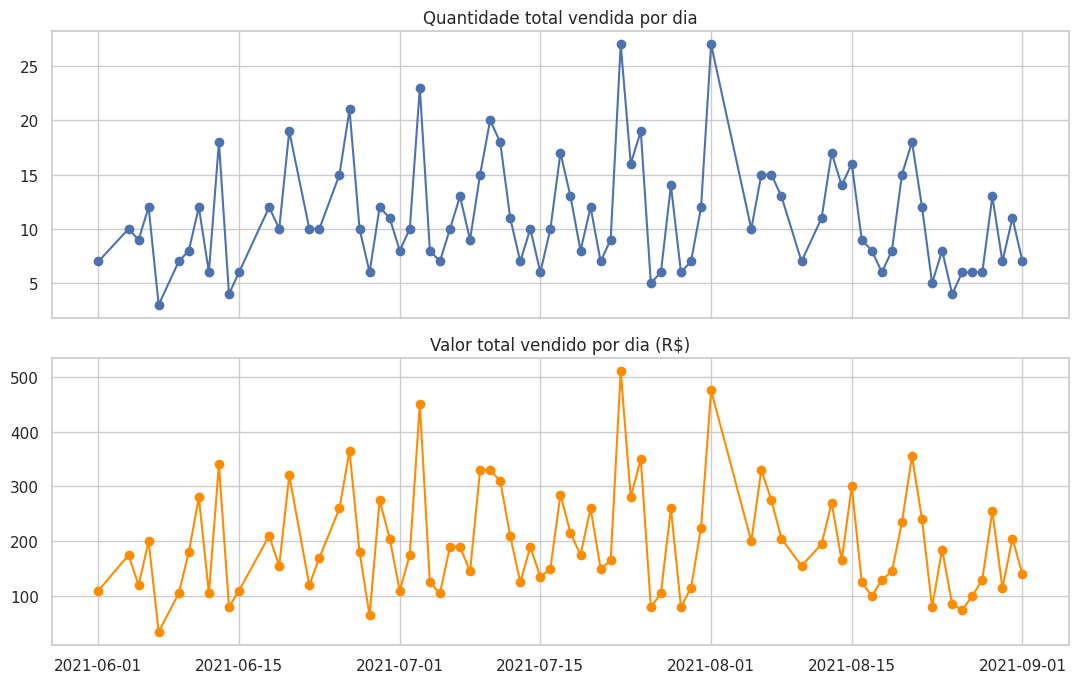

                                DATA  QUANTIDADE_TOTAL  VALOR_TOTAL
count                             81         81.000000    81.000000
mean   2021-07-18 17:11:06.666666752         11.049383   197.037037
min              2021-06-01 00:00:00          3.000000    35.000000
25%              2021-06-28 00:00:00          7.000000   120.000000
50%              2021-07-18 00:00:00         10.000000   180.000000
75%              2021-08-12 00:00:00         14.000000   260.000000
max              2021-09-01 00:00:00         27.000000   510.000000
std                              NaN          5.088962    97.707400


In [ ]:
# --- Série temporal diária de quantidade e valor vendidos ---
vendas_diarias = pl.montar_vendas_diarias(df_pedido)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(11, 7))
axes[0].plot(vendas_diarias["DATA"], vendas_diarias["QUANTIDADE_TOTAL"], marker="o")
axes[0].set_title("Quantidade total vendida por dia")
axes[1].plot(vendas_diarias["DATA"], vendas_diarias["VALOR_TOTAL"], marker="o", color="darkorange")
axes[1].set_title("Valor total vendido por dia (R$)")
plt.tight_layout()
plt.show()

print(vendas_diarias.describe())

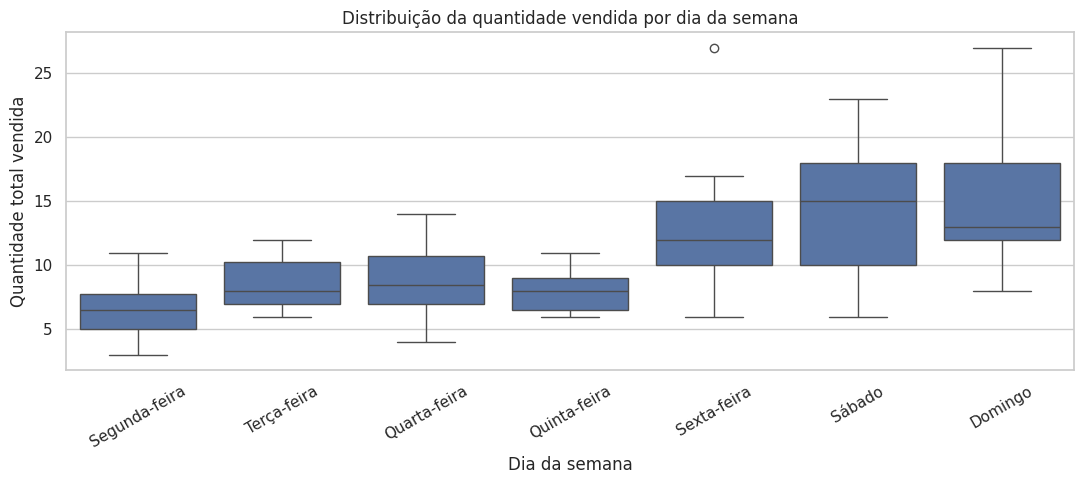

In [ ]:
# --- Padrão por dia da semana (em português) ---
plt.figure()
sns.boxplot(data=vendas_diarias, x="DIA_SEMANA", y="QUANTIDADE_TOTAL", order=pl.DIAS_SEMANA_PT)
plt.title("Distribuição da quantidade vendida por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Quantidade total vendida")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

  ID_ITEM  QUANTIDADE_TOTAL  VALOR_TOTAL  PARTICIPACAO_VALOR_%
3  item D               251       6275.0             39.317043
2  item C               216       4320.0             27.067669
1  item B               217       3255.0             20.394737
0  item A               211       2110.0             13.220551


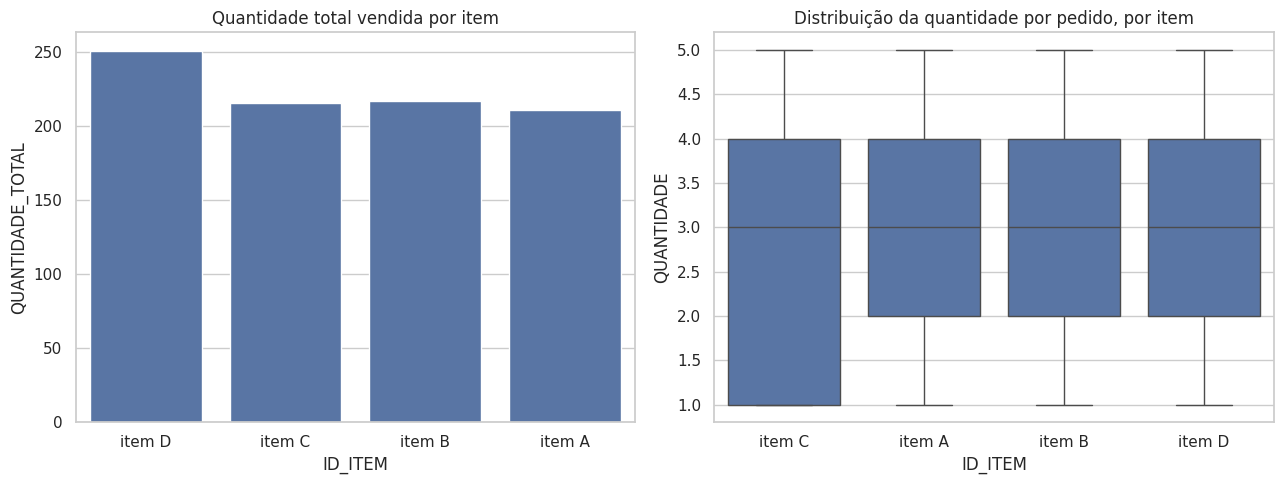

In [ ]:
# --- Mix de produtos: participação no total e distribuição por pedido ---
mix_produtos = pl.montar_mix_produtos(df_item_valor)

print(mix_produtos)
assert np.isclose(mix_produtos["VALOR_TOTAL"].sum(), df_item_valor["SUBTOTAL"].sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=mix_produtos, x="ID_ITEM", y="QUANTIDADE_TOTAL", ax=axes[0])
axes[0].set_title("Quantidade total vendida por item")

# Distribuição da quantidade por pedido, para cada item (não apenas o total agregado)
sns.boxplot(data=df_item_valor, x="ID_ITEM", y="QUANTIDADE", ax=axes[1])
axes[1].set_title("Distribuição da quantidade por pedido, por item")
plt.tight_layout()
plt.show()

## 4. Benchmark de modelos preditivos de demanda (rede)

Dado o curto período histórico disponível (~3 meses) e a ausência de
granularidade por unidade nos dados fornecidos, esta seção prevê a
**quantidade total diária vendida na rede** a partir de features de
calendário e de curto prazo (lags). Comparamos 4 modelos de regressão —
Linear, Random Forest, XGBoost e LightGBM — usando validação cruzada
temporal (expanding window) para escolher o mais adequado com evidência,
em vez de assumir uma escolha a priori.

O dia da semana é codificado como variável categórica (one-hot), não como
número ordinal (0-6): tratá-lo como número forçaria a regressão linear a
assumir que a demanda cresce monotonicamente de segunda a domingo, o que
não é uma suposição válida e amplifica erros nos dias de pico (ver seção
6, onde essa correção reduziu o erro em dias específicos de teste).

In [ ]:
# --- Construção de features e split treino/teste temporal ---
serie = vendas_diarias.set_index("DATA")["QUANTIDADE_TOTAL"].asfreq("D").fillna(0.0)
df_features = pl.construir_features(serie)
assert df_features.isna().sum().sum() == 0, "Ainda há NaNs após a criação de lags"
print(df_features.head())

treino, teste = pl.dividir_treino_teste(df_features)
assert treino.index.max() < teste.index.min(), "Split não é estritamente temporal"
print(f"Treino: {treino.index.min().date()} a {treino.index.max().date()} ({len(treino)} dias)")
print(f"Teste:  {teste.index.min().date()} a {teste.index.max().date()} ({len(teste)} dias)")

FEATURES = pl.features_colunas()
X_treino, y_treino = treino[FEATURES], treino["QUANTIDADE"]
X_teste, y_teste = teste[FEATURES], teste["QUANTIDADE"]

            QUANTIDADE  DIA_1  DIA_2  DIA_3  DIA_4  DIA_5  DIA_6  TENDENCIA  LAG_1  LAG_2  LAG_7
DATA                                                                                            
2021-06-08         0.0    1.0    0.0    0.0    0.0    0.0    0.0          7    3.0   12.0    7.0
2021-06-09         7.0    0.0    1.0    0.0    0.0    0.0    0.0          8    0.0    3.0    0.0
2021-06-10         8.0    0.0    0.0    1.0    0.0    0.0    0.0          9    7.0    0.0    0.0
2021-06-11        12.0    0.0    0.0    0.0    1.0    0.0    0.0         10    8.0    7.0   10.0
2021-06-12         6.0    0.0    0.0    0.0    0.0    1.0    0.0         11   12.0    8.0    9.0
Treino: 2021-06-08 a 2021-08-18 (72 dias)
Teste:  2021-08-19 a 2021-09-01 (14 dias)


In [ ]:
# --- Benchmark com validação cruzada temporal (TimeSeriesSplit) ---
# Cada modelo é avaliado em várias janelas de expansão dentro do próprio
# conjunto de treino, sem tocar no holdout de teste, para escolher o
# melhor com evidência empírica em vez de suposição.
df_benchmark_cv = pl.benchmark_modelos(X_treino, y_treino)
print("Benchmark de modelos (validação cruzada temporal, treino):")
print(df_benchmark_cv)

melhor_modelo_nome = df_benchmark_cv.iloc[0]["Modelo"]
print(f"\nModelo escolhido com base na validação cruzada: {melhor_modelo_nome}")

Benchmark de modelos (validação cruzada temporal, treino):
             Modelo    MAE_CV   RMSE_CV
0     Random Forest  4.687784  5.728480
1          LightGBM  5.274073  6.419443
2  Regressão Linear  5.575427  6.921825
3           XGBoost  5.676349  6.571394

Modelo escolhido com base na validação cruzada: Random Forest


In [ ]:
# --- Treinamento final do modelo escolhido e avaliação no holdout ---
modelo = pl.construir_modelos()[melhor_modelo_nome]
modelo.fit(X_treino, y_treino)
previsao_modelo = modelo.predict(X_teste)

print("Previsões (holdout de teste):", np.round(previsao_modelo, 1))
if hasattr(modelo, "coef_"):
    print("Coeficientes:", dict(zip(FEATURES, modelo.coef_.round(3))))
elif hasattr(modelo, "feature_importances_"):
    print("Importância das features:", dict(zip(FEATURES, modelo.feature_importances_.round(3))))

Previsões (holdout de teste): [10.7 13.2 15.7 14.2  7.5  7.   7.3  6.9 12.2 13.3 13.9  5.5  7.6  5.6]
Importância das features: {'DIA_1': np.float64(0.005), 'DIA_2': np.float64(0.026), 'DIA_3': np.float64(0.003), 'DIA_4': np.float64(0.032), 'DIA_5': np.float64(0.027), 'DIA_6': np.float64(0.059), 'TENDENCIA': np.float64(0.12), 'LAG_1': np.float64(0.142), 'LAG_2': np.float64(0.113), 'LAG_7': np.float64(0.472)}


## 5. Previsão de demanda por item

A previsão agregada da rede é útil para dimensionar compras totais, mas a
gestão de estoque no dia a dia precisa de uma previsão **por item**
(A, B, C, D). `pl.prever_por_item` replica a mesma abordagem de
features/lags para a série diária de cada item, usando o tipo de modelo
vencedor do benchmark acima.

In [ ]:
# --- Série diária de quantidade por item ---
pivot_item = pl.montar_pivot_item(df_item_valor)
print(pivot_item.head())

ID_ITEM     item A  item B  item C  item D
DATA                                      
2021-06-01     3.0     0.0     4.0     0.0
2021-06-02     0.0     0.0     0.0     0.0
2021-06-03     0.0     0.0     0.0     0.0
2021-06-04     0.0     6.0     3.0     1.0
2021-06-05     5.0     3.0     0.0     1.0


In [ ]:
# --- Previsão por item com o modelo vencedor do benchmark ---
df_resultado_item, previsoes_por_item = pl.prever_por_item(pivot_item, melhor_modelo_nome)
print(df_resultado_item)

  ID_ITEM       MAE      RMSE  ERRO_PADRAO
0  item A  1.814401  2.144546     1.955282
1  item B  2.104909  2.290841     1.574262
2  item C  1.889384  2.089804     2.142072
3  item D  2.675221  3.142132     3.231398


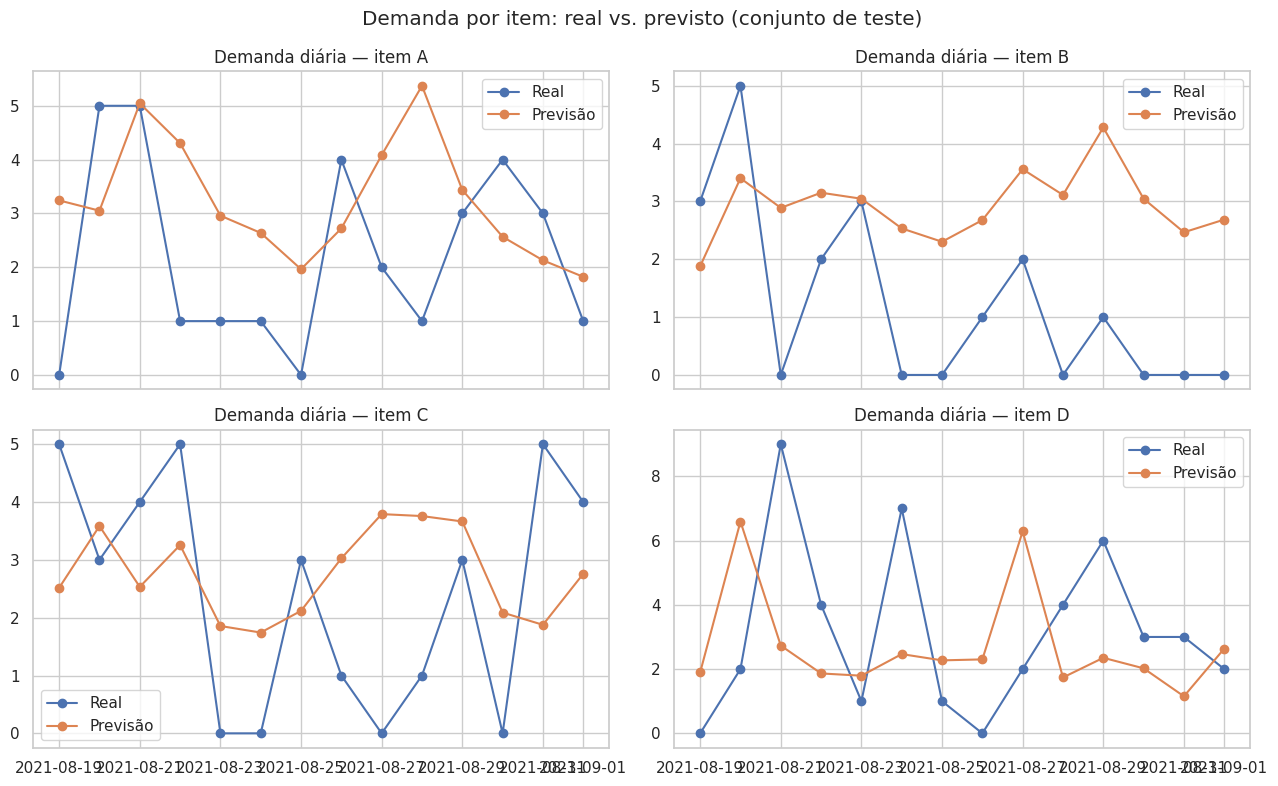

In [ ]:
# --- Previsto vs. real por item (holdout de teste) ---
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, item in zip(axes.ravel(), pivot_item.columns):
    y_real, y_prev = previsoes_por_item[item]
    ax.plot(y_real.index, y_real.values, label="Real", marker="o")
    ax.plot(y_real.index, y_prev, label="Previsão", marker="o")
    ax.set_title(f"Demanda diária — {item}")
    ax.legend()
fig.suptitle("Demanda por item: real vs. previsto (conjunto de teste)")
plt.tight_layout()
plt.show()

## 6. Avaliação final e recomendações de negócio

                   Modelo       MAE      RMSE
0           Random Forest  2.669604  3.249906
1  Baseline (naive lag-1)  3.928571  4.574776


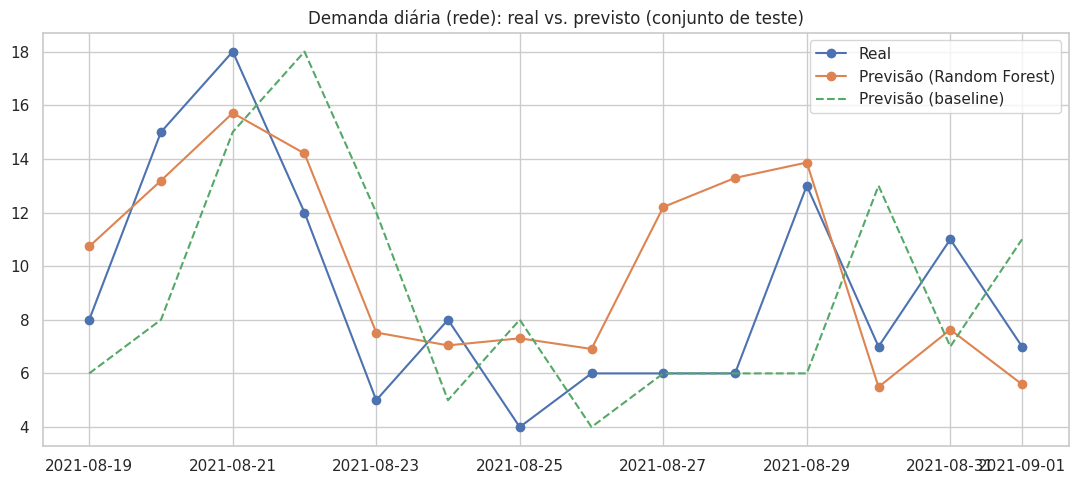

In [ ]:
# --- Avaliação do modelo agregado vs. baseline ingênuo ---
baseline_previsao = X_teste["LAG_1"].to_numpy()

mae_modelo = pl.mean_absolute_error(y_teste, previsao_modelo)
rmse_modelo = np.sqrt(pl.mean_squared_error(y_teste, previsao_modelo))

mae_baseline = pl.mean_absolute_error(y_teste, baseline_previsao)
rmse_baseline = np.sqrt(pl.mean_squared_error(y_teste, baseline_previsao))

comparativo = pd.DataFrame(
    {
        "Modelo": [melhor_modelo_nome, "Baseline (naive lag-1)"],
        "MAE": [mae_modelo, mae_baseline],
        "RMSE": [rmse_modelo, rmse_baseline],
    }
)
print(comparativo)

plt.figure()
plt.plot(y_teste.index, y_teste.values, label="Real", marker="o")
plt.plot(y_teste.index, previsao_modelo, label=f"Previsão ({melhor_modelo_nome})", marker="o")
plt.plot(y_teste.index, baseline_previsao, label="Previsão (baseline)", linestyle="--")
plt.title("Demanda diária (rede): real vs. previsto (conjunto de teste)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# --- Recomendação quantitativa de estoque de segurança por item ---
# Estoque de segurança = margem acima da previsão para absorver o erro do
# modelo, calculada com um fator de serviço (z) sobre o desvio padrão do
# erro de previsão observado no holdout de teste. z=1.65 ~ 95% de nível de
# serviço (aproximação didática; em produção, calibrar por item/SKU com
# mais histórico). Ver `pl.calcular_estoque_sugerido`.
df_resultado_item = pl.calcular_estoque_sugerido(df_resultado_item, previsoes_por_item, pivot_item)

print(df_resultado_item[
    ["ID_ITEM", "MAE", "RMSE", "ESTOQUE_SEGURANCA_SUGERIDO", "ESTOQUE_ALVO_SUGERIDO"]
])

  ID_ITEM       MAE      RMSE  ESTOQUE_SEGURANCA_SUGERIDO  ESTOQUE_ALVO_SUGERIDO
0  item A  1.814401  2.144546                           4                      6
1  item B  2.104909  2.290841                           3                      6
2  item C  1.889384  2.089804                           4                      7
3  item D  2.675221  3.142132                           6                      9


**Conclusões e recomendações:**

- **Qualidade de dados**: o campo `VALOR_TOTAL` chega vazio da origem em
  100% dos pedidos e precisa ser recalculado a partir dos itens vendidos.
  Recomenda-se corrigir esse cálculo na origem (sistema de pedidos) para
  eliminar essa reconstrução manual e o risco de erro associado.
- **Escolha do modelo com evidência**: o benchmark com validação cruzada
  temporal (Linear, Random Forest, XGBoost, LightGBM) definiu o modelo
  vencedor pelo menor erro médio nas janelas de validação (ver tabela de
  benchmark impressa acima, coluna `MAE_CV`) — a escolha não foi arbitrária.
- **Previsão por item**: além do total da rede, o modelo por item permite
  traduzir a previsão diretamente em uma sugestão de estoque de segurança
  e estoque-alvo por SKU (ver tabela acima), o que é mais próximo do que
  a Mr. Health precisa no dia a dia para reabastecimento. Um app Streamlit
  (`app/streamlit_app.py`) expõe essa mesma previsão em um painel de
  decisão interativo, sem exigir execução de código pela equipe de
  operações.
- **Volume de histórico**: com ~3 meses de dados e ~50 unidades agregadas
  em uma única série, o poder preditivo do modelo é limitado. À medida
  que mais meses de histórico e dados por unidade forem centralizados
  (objetivo de Wilson Luiz com o Data Lake/Data Warehouse), o modelo deve
  ser re-treinado por unidade e por item, o que tende a aumentar
  significativamente a precisão.
- **Limitação residual conhecida (picos isolados via `LAG_7`)**: no gráfico
  de "real vs. previsto" da rede, os dias 27–28/08/2021 seguem com previsão
  acima do real. A causa é que `LAG_7` captura o valor de sete dias antes
  (mesma posição na semana anterior) e, na semana de 20–21/08, houve um
  pico pontual (15 e 18 unidades); o modelo espera esse pico se repetir uma
  semana depois e ele não se repete. Já corrigimos um viés maior — o dia da
  semana estava codificado como número ordinal (0 a 6), forçando a suposição
  incorreta de que a demanda cresce monotonicamente de segunda a domingo —
  trocando para variáveis categóricas (one-hot), o que reduziu o MAE do
  modelo no holdout de teste de ~3,60 (regressão linear original) para
  ~2,67 (Random Forest, vencedor do benchmark após a correção). O erro
  remanescente nesses dois dias específicos é esperado dado o curto
  histórico (apenas ~11 repetições de cada dia da semana): o modelo não
  tem como distinguir uma sazonalidade semanal real de um pico isolado com
  tão poucos dados. Com mais meses de histórico, uma média suavizada de
  várias semanas anteriores (em vez de um único `LAG_7`) tende a atenuar
  esse efeito.
- **Automação (desejo de João Silva)**: os passos de ingestão, checagem
  de qualidade e reconstrução de valor deste notebook podem ser
  convertidos em um pipeline agendado, eliminando a consolidação manual
  em planilhas hoje feita pela equipe de Ricardo Martins.
- **Alertas de estoque**: a tabela de estoque-alvo por item já alimenta o
  painel de decisão do app Streamlit, que sinaliza "reabastecer" sempre
  que o estoque disponível informado ficar abaixo do estoque-alvo sugerido
  — o próximo passo natural deste modelo simplificado.